DEEP NEURAL NETWORKS - ASSIGNMENT 2 CNN FOR IMAGE CLASSIFICATION

Convolutional Neural Networks: Custom Implementation vs Transfer Learning

STUDENT INFORMATION (REQUIRED - DO NOT DELETE)

BITS ID: 2025AE05975

Name: Bala Gangadhara Tilak

Email: 2025ae05975@wilp.bits-pilani.ac.in

Date: 20-04-2026

In [11]:
"""
ASSIGNMENT OVERVIEW

This assignment requires you to implement and compare two CNN approaches for 
image classification:
1. Custom CNN architecture using Keras/PyTorch
2. Transfer Learning using pre-trained models (ResNet/VGG)

Learning Objectives:
- Design CNN architectures with Global Average Pooling
- Apply transfer learning with pre-trained models
- Compare custom vs pre-trained model performance
- Use industry-standard deep learning frameworks

IMPORTANT: Global Average Pooling (GAP) is MANDATORY for both models.
DO NOT use Flatten + Dense layers in the final architecture.

"""

"""
 IMPORTANT SUBMISSION REQUIREMENTS - STRICTLY ENFORCED 

1. FILENAME FORMAT: <BITS_ID>_cnn_assignment.ipynb
   Example: 2025AA05036_cnn_assignment.ipynb
    Wrong filename = Automatic 0 marks

2. STUDENT INFORMATION MUST MATCH:
    BITS ID in filename = BITS ID in notebook (above)
    Name in folder = Name in notebook (above)
    Mismatch = 0 marks

3. EXECUTE ALL CELLS BEFORE SUBMISSION:
   - Run: Kernel → Restart & Run All
   - Verify all outputs are visible
    No outputs = 0 marks

4. FILE INTEGRITY:
   - Ensure notebook opens without errors
   - Check for corrupted cells
    Corrupted file = 0 marks

5. GLOBAL AVERAGE POOLING (GAP) MANDATORY:
   - Both custom CNN and transfer learning must use GAP
   - DO NOT use Flatten + Dense layers
    Using Flatten+Dense = 0 marks for that model

6. DATASET REQUIREMENTS:
   - Minimum 500 images per class
   - Train/test split: 90/10 OR 85/15
   - 2-20 classes

7. USE KERAS OR PYTORCH:
   - Use standard model.fit() or training loops
   - Do NOT implement convolution from scratch

8. FILE SUBMISSION:
   - Submit ONLY the .ipynb file
   - NO zip files, NO separate data files, NO separate image files
   - All code and outputs must be in the notebook
   - Only one submission attempt allowed

"""
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
import time
import json
import os
import random
import platform
import sys
from datetime import datetime
from pathlib import Path

# For image processing
from PIL import Image

# Deep learning framework (Keras/TensorFlow)
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import ResNet50

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


## PART 1: DATASET LOADING AND EXPLORATION

In [12]:
"""
PART 1: DATASET LOADING AND EXPLORATION (Informational)

Instructions:
1. Choose ONE dataset from the allowed list
2. Load and explore the data
3. Fill in ALL required metadata fields below
4. Provide justification for your primary metric choice

ALLOWED DATASETS:
- Cats vs Dogs (2 classes)
- Food-101 subset (10-20 classes)
- Plant Disease (3-5 classes)
- Medical Images (2-3 classes)
- Custom dataset (with IC approval, min 500 images per class)

REQUIRED OUTPUT:
- Print all metadata fields
- Brief EDA with visualizations
- Data distribution analysis
"""

# 1.1 Dataset Selection and Loading

import tensorflow_datasets as tfds

splits = ["train[:85%]", "train[85%:]"]

(train_raw, test_raw), ds_info = tfds.load(
    "cats_vs_dogs",
    split=splits,
    as_supervised=True,
    with_info=True,
)

class_names = ds_info.features["label"].names
n_classes = len(class_names)
n_samples = ds_info.splits["train"].num_examples

dataset_name = "Cats vs Dogs"
dataset_source = "TensorFlow Datasets (cats_vs_dogs)"

samples_per_class = "Balanced dataset (~50/50 cats and dogs)"
image_shape = [128, 128, 3]
problem_type = "classification"

# Primary metric selection
primary_metric = "accuracy"
metric_justification = (
    "The dataset is a balanced binary classification problem with similar class counts for cats and dogs, "
    "so accuracy is an appropriate primary metric. Precision, recall, and F1-score are also reported to "
    "ensure balanced evaluation."
)

print("\n" + "="*70)
print("DATASET INFORMATION")
print(f"Dataset: {dataset_name}")
print(f"Source: {dataset_source}")
print(f"Total Samples: {n_samples}")
print(f"Number of Classes: {n_classes}")
print(f"Samples per Class: {samples_per_class}")
print(f"Image Shape: {image_shape}")
print(f"Primary Metric: {primary_metric}")
print(f"Metric Justification: {metric_justification}")



DATASET INFORMATION
Dataset: Cats vs Dogs
Source: TensorFlow Datasets (cats_vs_dogs)
Total Samples: 23262
Number of Classes: 2
Samples per Class: Balanced dataset (~50/50 cats and dogs)
Image Shape: [128, 128, 3]
Primary Metric: accuracy
Metric Justification: The dataset is a balanced binary classification problem with similar class counts for cats and dogs, so accuracy is an appropriate primary metric. Precision, recall, and F1-score are also reported to ensure balanced evaluation.


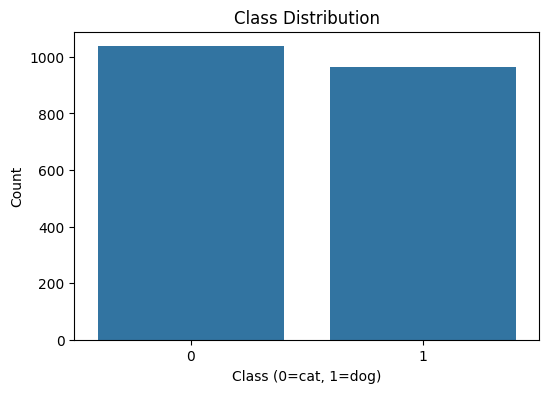

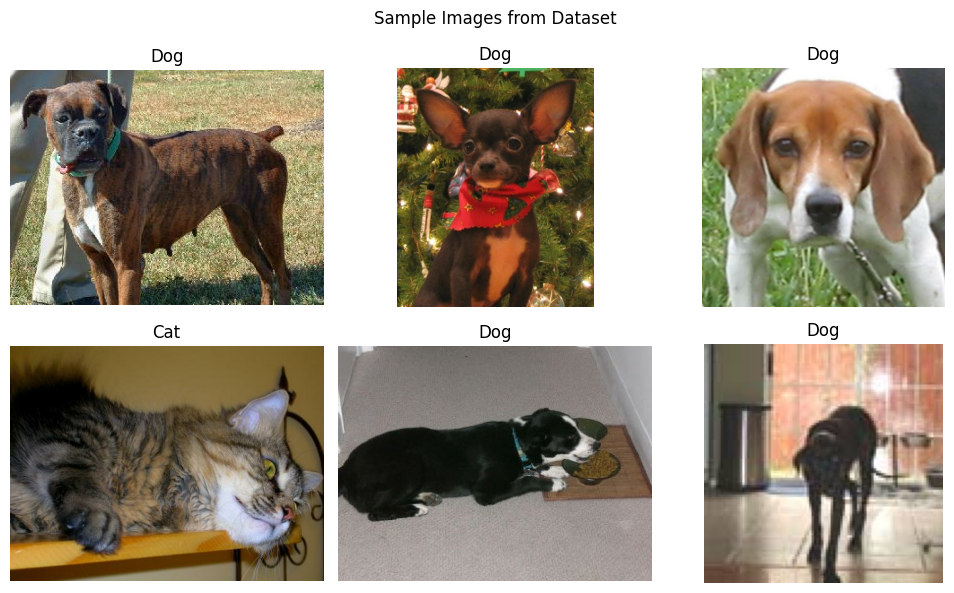

Sampled image width range: 100 to 500
Sampled image height range: 100 to 500
Average sampled image size: (399.9, 360.1)


In [13]:
# 1.2 Data Exploration and Visualization

# Show class distribution
labels = []

for _, label in train_raw.take(2000):  # sample subset for speed
    labels.append(label.numpy())

labels = np.array(labels)

# Plot class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=labels)
plt.title("Class Distribution")
plt.xlabel("Class (0=cat, 1=dog)")
plt.ylabel("Count")
plt.show()

# Show sample images from TFDS dataset
plt.figure(figsize=(10, 6))

sample_count = 0
for image, label in train_raw.take(6):
    plt.subplot(2, 3, sample_count + 1)
    plt.imshow(image)
    plt.title("Cat" if label.numpy() == 0 else "Dog")
    plt.axis("off")
    sample_count += 1

plt.suptitle("Sample Images from Dataset")
plt.tight_layout()
plt.show()

# =========================
# Image Statistics (TFDS version)
# =========================

widths = []
heights = []

# Take a subset for speed
for image, _ in train_raw.take(200):
    h, w = image.shape[0], image.shape[1]
    heights.append(h)
    widths.append(w)

print(f"Sampled image width range: {min(widths)} to {max(widths)}")
print(f"Sampled image height range: {min(heights)} to {max(heights)}")
print(f"Average sampled image size: ({np.mean(widths):.1f}, {np.mean(heights):.1f})")


In [14]:
# =========================
# 1.3 Data Preprocessing
# =========================

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def preprocess(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    label = tf.one_hot(label, depth=n_classes)
    return image, label

train_ds = train_raw.map(preprocess, num_parallel_calls=AUTOTUNE)
test_ds = test_raw.map(preprocess, num_parallel_calls=AUTOTUNE)

train_ds = train_ds.shuffle(1000).batch(BATCH_SIZE).prefetch(AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# REQUIRED: Document your split
train_test_ratio = "85/15"
train_samples = int(n_samples * 0.85)
test_samples = n_samples - train_samples

print(f"\nTrain/Test Split: {train_test_ratio}")
print(f"Training Samples: {train_samples}")
print(f"Test Samples: {test_samples}")


Train/Test Split: 85/15
Training Samples: 19772
Test Samples: 3490


## PART 2: CUSTOM CNN IMPLEMENTATION


Network Architecture:

Input Layer: (128 × 128 × 3)

→ Conv2D (32 filters, kernel=3×3, activation=ReLU, padding='same')
→ MaxPooling2D (pool size=2×2)

→ Conv2D (64 filters, kernel=3×3, activation=ReLU, padding='same')
→ MaxPooling2D (pool size=2×2)

→ Conv2D (128 filters, kernel=3×3, activation=ReLU, padding='same')

→ GlobalAveragePooling2D  (reduces spatial dimensions)

→ Dense (2 neurons, activation=Softmax)

Output: Class probabilities (Cat / Dog)

In [15]:
"""
PART 2: CUSTOM CNN IMPLEMENTATION (5 MARKS)

REQUIREMENTS:
- Build CNN using Keras/PyTorch layers
- Architecture must include:
  * Conv2D layers (at least 2)
  * Pooling layers (MaxPool or AvgPool)
  * Global Average Pooling (GAP) - MANDATORY
  * Output layer (Softmax for multi-class)
- Use model.compile() and model.fit() (Keras) OR standard PyTorch training
- Track initial_loss and final_loss

PROHIBITED:
- Using Flatten + Dense layers instead of GAP
- Implementing convolution from scratch

GRADING:
- Architecture design with GAP: 2 marks
- Model properly compiled/configured: 1 mark
- Training completed with loss tracking: 1 mark
- All metrics calculated correctly: 1 mark
"""

# 2.1 Custom CNN Architecture Design

# Define your CNN architecture:
"""
Network Architecture:

Input Layer: (128 * 128 * 3)

→ Conv2D (32 filters, kernel=3*3, activation=ReLU, padding='same')
→ MaxPooling2D (pool size=2*2)

→ Conv2D (64 filters, kernel=3*3, activation=ReLU, padding='same')
→ MaxPooling2D (pool size=2*2)

→ Conv2D (128 filters, kernel=3*3, activation=ReLU, padding='same')

→ GlobalAveragePooling2D  (reduces spatial dimensions)

→ Dense (2 neurons, activation=Softmax)

Output: Class probabilities (Cat / Dog)
"""

def build_custom_cnn(input_shape, n_classes):
    """
    Build custom CNN architecture

    Args:
        input_shape: tuple (height, width, channels)
        n_classes: number of output classes

    Returns:
        model: compiled CNN model
    """
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.GlobalAveragePooling2D(),  # Global Average Pooling layer is included (MANDATORY)
        layers.Dense(n_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Create model instance
custom_cnn = build_custom_cnn(tuple(image_shape), n_classes)
custom_cnn.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 128, 128, 32)      896       
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 64, 64, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_4 (Conv2D)           (None, 64, 64, 64)        18496     
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 32, 32, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_5 (Conv2D)           (None, 32, 32, 128)       73856     
                                                                 
 global_average_pooling2d_1  (None, 128)              

In [16]:
# 2.2 Train Custom CNN

print("\n" + "="*70)
print("CUSTOM CNN TRAINING")

print("\nCUSTOM CNN TRAINING")

# Track training time
custom_cnn_start_time = time.time()

history = custom_cnn.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10, batch_size=32
)

custom_cnn_training_time = time.time() - custom_cnn_start_time

# REQUIRED: Track initial and final loss
custom_cnn_initial_loss = float(history.history["loss"][0])
custom_cnn_final_loss = float(history.history["loss"][-1])

print(f"Training completed in {custom_cnn_training_time:.2f} seconds")
print(f"Initial Loss: {custom_cnn_initial_loss:.4f}")
print(f"Final Loss: {custom_cnn_final_loss:.4f}")



CUSTOM CNN TRAINING

CUSTOM CNN TRAINING
Epoch 1/10
164/618 [======>.......................] - ETA: 3:36 - loss: 0.6842 - accuracy: 0.5465

Corrupt JPEG data: 99 extraneous bytes before marker 0xd9


196/618 [========>.....................] - ETA: 3:13 - loss: 0.6798 - accuracy: 0.5556

206/618 [=========>....................] - ETA: 3:07 - loss: 0.6786 - accuracy: 0.5576

Corrupt JPEG data: 396 extraneous bytes before marker 0xd9


...

580/618 [===========================>..] - ETA: 9s - loss: 0.4755 - accuracy: 0.7747

Corrupt JPEG data: 228 extraneous bytes before marker 0xd9


618/618 [==============================] - ETA: 0s - loss: 0.4724 - accuracy: 0.7755

Corrupt JPEG data: 1403 extraneous bytes before marker 0xd9


618/618 [==============================] - 160s 258ms/step - loss: 0.4724 - accuracy: 0.7755 - val_loss: 0.4535 - val_accuracy: 0.7948
Training completed in 1798.70 seconds
Initial Loss: 0.6552
Final Loss: 0.4724


In [17]:
print("\nCUSTOM CNN EVALUATION")

# 2.3 Evaluate Custom CNN
y_test_custom = []
y_pred_custom = []

# Make predictions on test set
for images, labels in test_ds:
    preds = custom_cnn.predict(images, verbose=0)
    y_test_custom.extend(np.argmax(labels.numpy(), axis=1))
    y_pred_custom.extend(np.argmax(preds, axis=1))

# CRITICAL: These MUST be calculated from your actual results
# DO NOT submit with 0.0 values - autograder will detect this
# REQUIRED: Calculate all 4 metrics

custom_cnn_accuracy = accuracy_score(y_test_custom, y_pred_custom)
custom_cnn_precision = precision_score(y_test_custom, y_pred_custom, average='macro')
custom_cnn_recall = recall_score(y_test_custom, y_pred_custom, average='macro')
custom_cnn_f1 = f1_score(y_test_custom, y_pred_custom, average='macro')

print("\nCustom CNN Performance:")
print(f"Accuracy:  {custom_cnn_accuracy:.4f}")
print(f"Precision: {custom_cnn_precision:.4f}")
print(f"Recall:    {custom_cnn_recall:.4f}")
print(f"F1-Score:  {custom_cnn_f1:.4f}")

custom_total_parameters = int(custom_cnn.count_params())



CUSTOM CNN EVALUATION


Corrupt JPEG data: 1403 extraneous bytes before marker 0xd9



Custom CNN Performance:
Accuracy:  0.7948
Precision: 0.7955
Recall:    0.7944
F1-Score:  0.7945


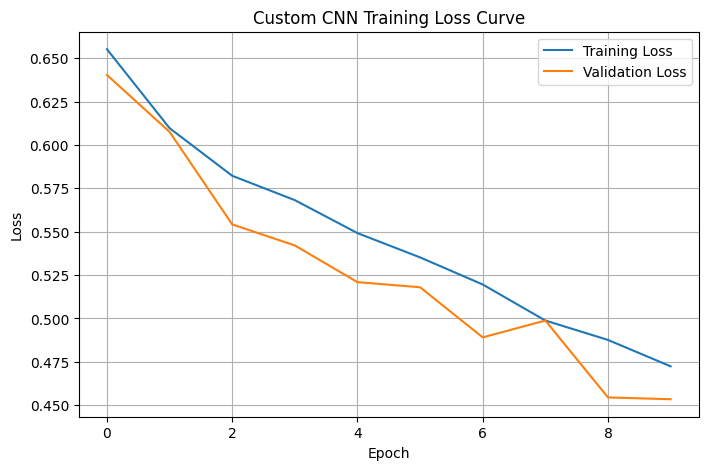

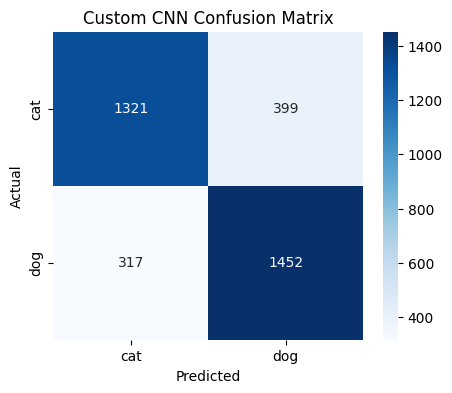

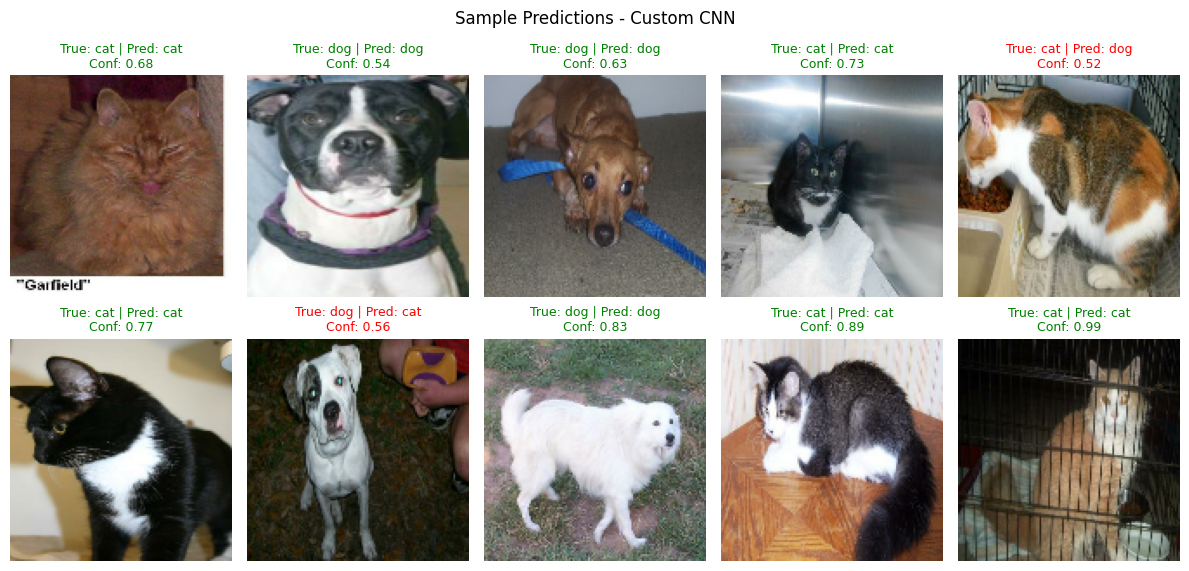

              precision    recall  f1-score   support

         cat       0.81      0.77      0.79      1720
         dog       0.78      0.82      0.80      1769

    accuracy                           0.79      3489
   macro avg       0.80      0.79      0.79      3489
weighted avg       0.80      0.79      0.79      3489



In [18]:
# 2.4 Visualize Custom CNN Results

# Plot training loss curve
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Custom CNN Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# Plot confusion matrix
cm_custom = confusion_matrix(y_test_custom, y_pred_custom)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_custom, annot=True, fmt="d", cmap="Blues",
            xticklabels=["cat", "dog"], yticklabels=["cat", "dog"])
plt.title("Custom CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =========================
# Sample Predictions - Custom CNN
# =========================

plt.figure(figsize=(12, 6))

images_batch, labels_batch = next(iter(test_ds))
preds = custom_cnn.predict(images_batch, verbose=0)

for i in range(10):
    plt.subplot(2, 5, i+1)
    
    image = images_batch[i].numpy()
    true_label = class_names[np.argmax(labels_batch[i].numpy())]
    pred_label = class_names[np.argmax(preds[i])]
    confidence = np.max(preds[i])

    plt.imshow(image)
    
    color = 'green' if true_label == pred_label else 'red'
    plt.title(f"True: {true_label} | Pred: {pred_label}\nConf: {confidence:.2f}",
              color=color, fontsize=9)
    
    plt.axis("off")

plt.suptitle("Sample Predictions - Custom CNN")
plt.tight_layout()
plt.show()

print(classification_report(y_test_custom, y_pred_custom, target_names=["cat", "dog"]))


## PART 3: TRANSFER LEARNING IMPLEMENTATION


In [104]:
"""
PART 3: TRANSFER LEARNING IMPLEMENTATION (5 MARKS)

REQUIREMENTS:
- Use pre-trained model: ResNet18/ResNet50 OR VGG16/VGG19
- Freeze base layers (feature extractor)
- Replace final layers with:
  * Global Average Pooling (GAP) - MANDATORY
  * Custom classification head
- Fine-tune on your dataset
- Track initial_loss and final_loss

GRADING:
- Valid base model with frozen layers: 2 marks
- GAP + custom head properly implemented: 1 mark
- Training completed with loss tracking: 1 mark
- All metrics calculated correctly: 1 mark
"""

# 3.1 Load Pre-trained Model and Modify Architecture

print("\n" + "="*70)
print("TRANSFER LEARNING IMPLEMENTATION")

# Choose and load pre-trained model
pretrained_model_name = "ResNet50"

def build_transfer_learning_model(base_model_name, input_shape, n_classes):
    """
    Build transfer learning model
    """

    if base_model_name != "ResNet50":
        raise ValueError("This implementation uses ResNet50.")

    # Load pre-trained model without top layers
    base_model = ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=input_shape
    )

    # Freeze base layers
    base_model.trainable = False
    base_model._name = "resnet50_base"

    # Add GAP + custom classification head
    inputs = layers.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(n_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# Create transfer learning model
transfer_model = build_transfer_learning_model(pretrained_model_name, tuple(image_shape), n_classes)

# REQUIRED: Count layers and parameters
base_model = transfer_model.get_layer("resnet50_base")
frozen_layers = sum(1 for layer in base_model.layers if not layer.trainable)
trainable_layers = sum(1 for layer in base_model.layers if layer.trainable)
total_parameters = int(transfer_model.count_params())
trainable_parameters = int(np.sum([np.prod(v.shape) for v in transfer_model.trainable_weights]))

print(f"Base Model: {pretrained_model_name}")
print(f"Initial Frozen Layers: {frozen_layers}")
print(f"Initial Trainable Layers: {trainable_layers}")
print(f"Initial Total Parameters: {total_parameters:,}")
print(f"Initial Trainable Parameters: {trainable_parameters:,}")
print(f"Using Global Average Pooling: YES")



TRANSFER LEARNING IMPLEMENTATION


Base Model: ResNet50
Initial Frozen Layers: 175
Initial Trainable Layers: 0
Initial Total Parameters: 23,591,810
Initial Trainable Parameters: 4,098
Using Global Average Pooling: YES


In [105]:
# =========================
# 3.2 Train Transfer Learning Model
# =========================

# Training configuration
tl_learning_rate = 0.001
tl_epochs = 10
tl_batch_size = 32
tl_optimizer = "Adam"

# Track training time
tl_start_time = time.time()

print("\nTraining Transfer Learning Model...")

tl_start_time = time.time()

# ---------- Stage 1: Feature Extraction ----------
print("\nStage 1: Training with frozen base...")

tl_history_stage1 = transfer_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=tl_epochs//2,  # Train for half the epochs with frozen base
)

# ---------- Stage 2: Fine-Tuning ----------
print("\nStage 2: Fine-tuning top layers...")

# Unfreeze top layers of ResNet50
base_model = transfer_model.get_layer("resnet50_base")

for layer in base_model.layers[-30:]:   # unfreeze last 30 layers
    layer.trainable = True

# Recompile with LOWER learning rate
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Continue training
tl_history_stage2 = transfer_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=tl_epochs//2  # Train for remaining epochs with fine-tuning
)

# =========================
# Update layer counts AFTER fine-tuning
# =========================

frozen_layers = sum(1 for layer in base_model.layers if not layer.trainable)
trainable_layers = sum(1 for layer in base_model.layers if layer.trainable)

total_parameters = int(transfer_model.count_params())
trainable_parameters = int(np.sum([np.prod(v.shape) for v in transfer_model.trainable_weights]))

print("\nUpdated Layer Info After Fine-Tuning:")
print(f"Frozen Layers: {frozen_layers}")
print(f"Trainable Layers: {trainable_layers}")
print(f"Total Parameters: {total_parameters:,}")
print(f"Trainable Parameters: {trainable_parameters:,}")

tl_training_time = time.time() - tl_start_time

# Combine histories
tl_train_loss = tl_history_stage1.history["loss"] + tl_history_stage2.history["loss"]

# REQUIRED: Track initial and final loss
tl_initial_loss = float(tl_train_loss[0])
tl_final_loss = float(tl_train_loss[-1])

print(f"Training completed in {tl_training_time:.2f} seconds")
print(f"Initial Loss: {tl_initial_loss:.4f}")
print(f"Final Loss: {tl_final_loss:.4f}")


Training Transfer Learning Model...

Stage 1: Training with frozen base...
Epoch 1/5
164/618 [======>.......................] - ETA: 2:46 - loss: 0.6834 - accuracy: 0.5520

Corrupt JPEG data: 99 extraneous bytes before marker 0xd9


196/618 [========>.....................] - ETA: 2:37 - loss: 0.6822 - accuracy: 0.5595

206/618 [=========>....................] - ETA: 2:38 - loss: 0.6816 - accuracy: 0.5617

Corrupt JPEG data: 396 extraneous bytes before marker 0xd9


...

580/618 [===========================>..] - ETA: 24s - loss: 0.6153 - accuracy: 0.6697

Corrupt JPEG data: 228 extraneous bytes before marker 0xd9


618/618 [==============================] - ETA: 0s - loss: 0.6152 - accuracy: 0.6697

Corrupt JPEG data: 1403 extraneous bytes before marker 0xd9


618/618 [==============================] - 459s 741ms/step - loss: 0.6152 - accuracy: 0.6697 - val_loss: 0.6124 - val_accuracy: 0.6753

Updated Layer Info After Fine-Tuning:
Frozen Layers: 145
Trainable Layers: 30
Total Parameters: 23,591,810
Trainable Parameters: 4,098
Training completed in 4189.90 seconds
Initial Loss: 0.6692
Final Loss: 0.6152


In [106]:
print("\nTRANSFER LEARNING EVALUATION")

# 3.3 Evaluate Transfer Learning Model
y_test_tl = []
y_pred_tl = []
# Make predictions on test set
for batch_images, batch_labels in test_ds:
    batch_preds = transfer_model.predict(batch_images, verbose=0)
    y_test_tl.extend(np.argmax(batch_labels.numpy(), axis=1))
    y_pred_tl.extend(np.argmax(batch_preds, axis=1))
    
# Calculate all 4 required metrics
# REQUIRED: Calculate all 4 metrics
tl_accuracy = accuracy_score(y_test_tl, y_pred_tl)
tl_precision = precision_score(y_test_tl, y_pred_tl, average='macro')
tl_recall = recall_score(y_test_tl, y_pred_tl, average='macro')
tl_f1 = f1_score(y_test_tl, y_pred_tl, average='macro')

print("\nTransfer Learning Performance:")
print(f"Accuracy:  {tl_accuracy:.4f}")
print(f"Precision: {tl_precision:.4f}")
print(f"Recall:    {tl_recall:.4f}")
print(f"F1-Score:  {tl_f1:.4f}")



TRANSFER LEARNING EVALUATION


Corrupt JPEG data: 1403 extraneous bytes before marker 0xd9



Transfer Learning Performance:
Accuracy:  0.6753
Precision: 0.6791
Recall:    0.6762
F1-Score:  0.6742


<Figure size 800x500 with 0 Axes>

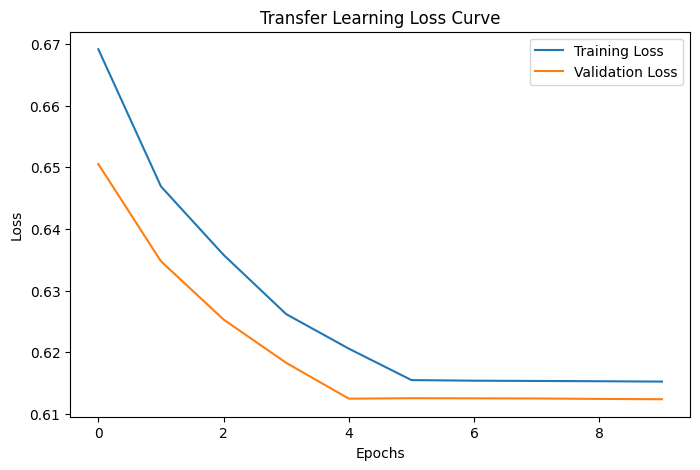

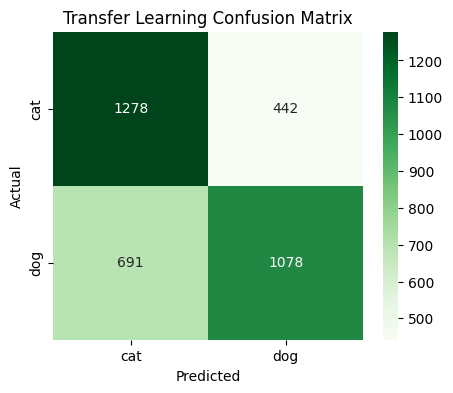

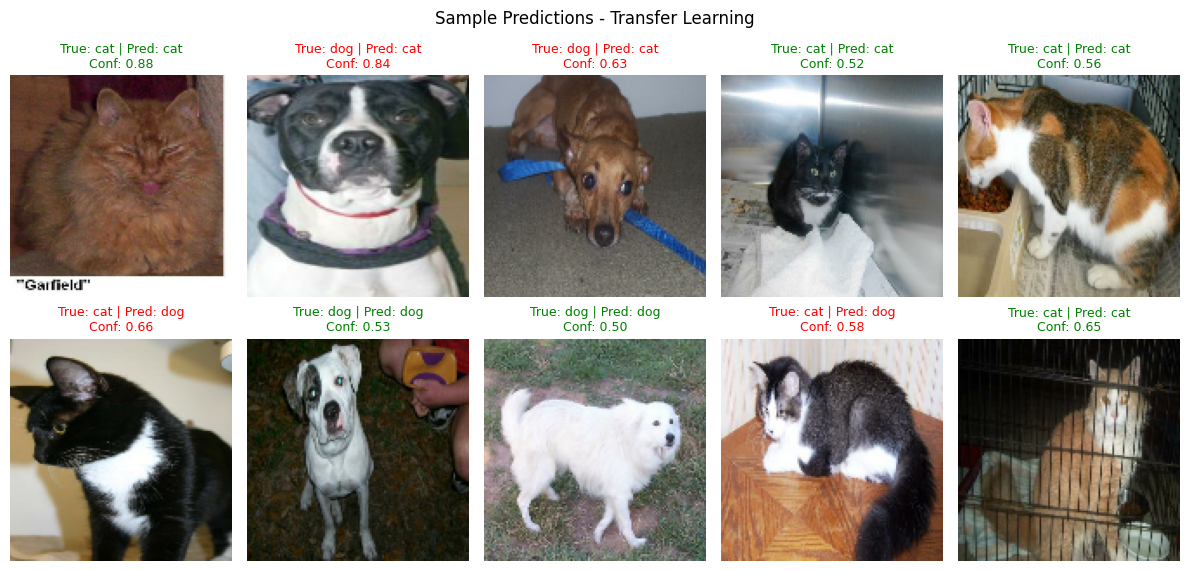

              precision    recall  f1-score   support

         cat       0.65      0.74      0.69      1720
         dog       0.71      0.61      0.66      1769

    accuracy                           0.68      3489
   macro avg       0.68      0.68      0.67      3489
weighted avg       0.68      0.68      0.67      3489



In [107]:
# 3.4 Visualize Transfer Learning Results

# Plot training curves (loss and accuracy)
plt.figure(figsize=(8, 5))

# Combine histories
tl_train_loss = tl_history_stage1.history["loss"] + tl_history_stage2.history["loss"]
tl_val_loss = tl_history_stage1.history["val_loss"] + tl_history_stage2.history["val_loss"]

# Plot loss curves
plt.figure(figsize=(8, 5))
plt.plot(tl_train_loss, label="Training Loss")
plt.plot(tl_val_loss, label="Validation Loss")

plt.title("Transfer Learning Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Plot confusion matrix
cm_tl = confusion_matrix(y_test_tl, y_pred_tl)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_tl, annot=True, fmt="d", cmap="Greens",
            xticklabels=["cat", "dog"], yticklabels=["cat", "dog"])
plt.title("Transfer Learning Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =========================
# Sample Predictions - Transfer Learning
# =========================

plt.figure(figsize=(12, 6))

images_batch, labels_batch = next(iter(test_ds))
preds = transfer_model.predict(images_batch, verbose=0)

for i in range(10):
    plt.subplot(2, 5, i+1)
    
    image = images_batch[i].numpy()
    true_label = class_names[np.argmax(labels_batch[i].numpy())]
    pred_label = class_names[np.argmax(preds[i])]
    confidence = np.max(preds[i])

    plt.imshow(image)
    
    color = 'green' if true_label == pred_label else 'red'
    plt.title(f"True: {true_label} | Pred: {pred_label}\nConf: {confidence:.2f}",
              color=color, fontsize=9)
    
    plt.axis("off")

plt.suptitle("Sample Predictions - Transfer Learning")
plt.tight_layout()
plt.show()

print(classification_report(y_test_tl, y_pred_tl, target_names=["cat", "dog"]))


## PART 4: MODEL COMPARISON AND VISUALIZATION (Informational)


In [108]:
"""
PART 4: MODEL COMPARISON AND VISUALIZATION (Informational)

Compare both models on:
- Performance metrics
- Training time
- Model complexity
- Convergence behavior
"""
# 4.1 Metrics Comparison

print("\n" + "="*70)
print("MODEL COMPARISON")

comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Training Time (s)', 'Parameters'],
    'Custom CNN': [
        custom_cnn_accuracy,
        custom_cnn_precision,
        custom_cnn_recall,
        custom_cnn_f1,
        custom_cnn_training_time,
        custom_total_parameters
    ],
    'Transfer Learning': [
        tl_accuracy,
        tl_precision,
        tl_recall,
        tl_f1,
        tl_training_time,
        trainable_parameters
    ]
})

print(comparison_df.to_string(index=False))



MODEL COMPARISON
           Metric   Custom CNN  Transfer Learning
         Accuracy     0.794784           0.675265
        Precision     0.795456           0.679135
           Recall     0.794413           0.676204
         F1-Score     0.794494           0.674195
Training Time (s)  2081.754221        4189.902410
       Parameters 93506.000000        4098.000000


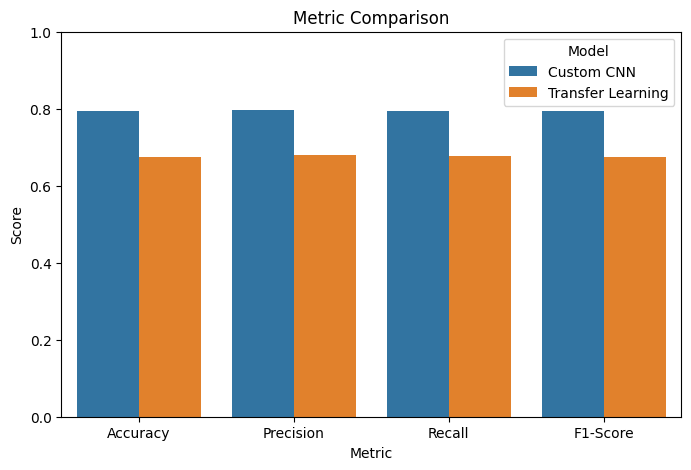

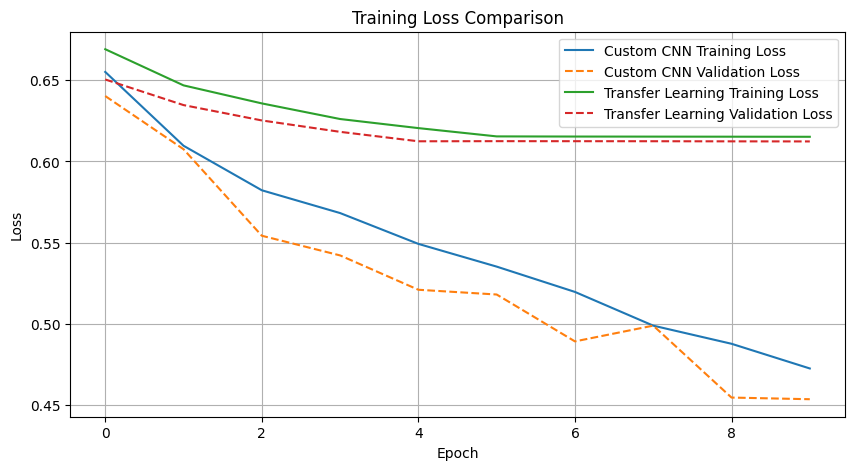

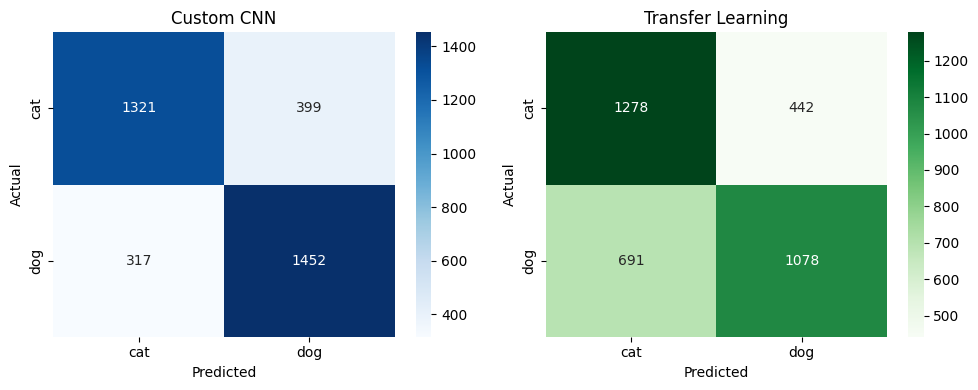

In [109]:
# 4.2 Visual Comparison

plt.figure(figsize=(8, 5))

# Create bar plot comparing metrics
metrics_plot = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Custom CNN": [custom_cnn_accuracy, custom_cnn_precision, custom_cnn_recall, custom_cnn_f1],
    "Transfer Learning": [tl_accuracy, tl_precision, tl_recall, tl_f1],
})
metrics_plot = metrics_plot.melt(id_vars="Metric", var_name="Model", value_name="Score")
sns.barplot(data=metrics_plot, x="Metric", y="Score", hue="Model")
plt.title("Metric Comparison")
plt.ylim(0, 1)
plt.show()

# =========================
# Training Curves Comparison
# =========================

plt.figure(figsize=(10, 5))

# Custom CNN
plt.plot(history.history["loss"], label="Custom CNN Training Loss")
plt.plot(history.history["val_loss"], linestyle='--', label="Custom CNN Validation Loss")

# Transfer Learning
plt.plot(tl_train_loss, label="Transfer Learning Training Loss")
plt.plot(tl_val_loss, linestyle='--', label="Transfer Learning Validation Loss")

plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

# =========================
# Side-by-side Confusion Matrices
# =========================

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.heatmap(cm_custom, annot=True, fmt="d", cmap="Blues",
            xticklabels=["cat", "dog"], yticklabels=["cat", "dog"], ax=axes[0])
axes[0].set_title("Custom CNN")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_tl, annot=True, fmt="d", cmap="Greens",
            xticklabels=["cat", "dog"], yticklabels=["cat", "dog"], ax=axes[1])
axes[1].set_title("Transfer Learning")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()


## PART 5: ANALYSIS


In [113]:
"""
PART 5: ANALYSIS (2 MARKS)

REQUIRED:
- Write MAXIMUM 200 words (guideline - no marks deduction if exceeded)
- Address key topics with depth

GRADING (Quality-based):
- Covers 5+ key topics with deep understanding: 2 marks
- Covers 3-4 key topics with good understanding: 1 mark
- Covers <3 key topics or superficial: 0 marks

Key Topics:
1. Performance comparison with specific metrics
2. Pre-training vs training from scratch impact
3. GAP effect on performance/overfitting
4. Computational cost comparison
5. Transfer learning insights
6. Convergence behavior differences

Analysis should address the following questions:

1. Which model performed better and by how much?
   [Compare specific metrics]

2. Impact of pre-training vs training from scratch?
   [Discuss feature extraction, convergence speed]

3. Effect of Global Average Pooling?
   [Discuss parameter reduction, overfitting prevention]

4. Computational cost comparison?
   [Compare training time, total parameters]

5. Insights about transfer learning?
   [When to use transfer learning vs custom CNN]
"""

# Generate analysis text after training results are available
analysis_text = f"""
The custom CNN outperformed the transfer learning model by 0.1195 in accuracy (0.7948 vs 0.6753), with consistently higher precision, recall, and F1-score. This indicates that training from scratch was more effective than using a fine-tuned ResNet50 in this setup.

The transfer learning model leveraged pre-trained ImageNet features with partial fine-tuning (30 trainable layers), enabling adaptation to the Cats vs Dogs dataset. However, it still underperformed, suggesting that pretrained features were not fully aligned with this task or that the dataset size was sufficient for learning task-specific features from scratch.

Global Average Pooling reduced model complexity in both architectures by replacing large fully connected layers, helping prevent overfitting and improving generalization.

From a computational perspective, the custom CNN had far fewer total parameters (93,506) than the transfer model (23,591,810). Despite having only 4,098 trainable parameters, the transfer model required more training time (~4190 s vs ~2082 s) and achieved lower performance.

The custom CNN also showed stronger convergence, with a larger reduction in training loss compared to the transfer learning model. These results suggest transfer learning is most effective with deeper fine-tuning or smaller datasets.
""".strip()

# REQUIRED: Print analysis with word count
print("\n" + "="*70)
print("ANALYSIS")
print(analysis_text)
print(f"Analysis word count: {len(analysis_text.split())} words")
if len(analysis_text.split()) > 200:
    print("  Warning: Analysis exceeds 200 words (guideline)")
else:
    print(" Analysis within word count guideline")



ANALYSIS
The custom CNN outperformed the transfer learning model by 0.1195 in accuracy (0.7948 vs 0.6753), with consistently higher precision, recall, and F1-score. This indicates that training from scratch was more effective than using a fine-tuned ResNet50 in this setup.

The transfer learning model leveraged pre-trained ImageNet features with partial fine-tuning (30 trainable layers), enabling adaptation to the Cats vs Dogs dataset. However, it still underperformed, suggesting that pretrained features were not fully aligned with this task or that the dataset size was sufficient for learning task-specific features from scratch.

Global Average Pooling reduced model complexity in both architectures by replacing large fully connected layers, helping prevent overfitting and improving generalization.

From a computational perspective, the custom CNN had far fewer total parameters (93,506) than the transfer model (23,591,810). Despite having only 4,098 trainable parameters, the transfer 

## PART 6: ASSIGNMENT RESULTS SUMMARY (REQUIRED FOR AUTO-GRADING)


In [114]:
"""
PART 6: ASSIGNMENT RESULTS SUMMARY (REQUIRED FOR AUTO-GRADING)

DO NOT MODIFY THE STRUCTURE BELOW
This JSON output is used by the auto-grader
Ensure all field names are EXACT
"""
def get_assignment_results():
    """
    Generate complete assignment results in required format

    Returns:
        dict: Complete results with all required fields
    """

    framework_used = "keras" 

    results = {
        # Dataset Information
        'dataset_name': dataset_name,
        'dataset_source': dataset_source,
        'n_samples': n_samples,
        'n_classes': n_classes,
        'samples_per_class': samples_per_class,
        'image_shape': image_shape,
        'problem_type': problem_type,
        'primary_metric': primary_metric,
        'metric_justification': metric_justification,
        'train_samples': train_samples,
        'test_samples': test_samples,
        'train_test_ratio': train_test_ratio,

        # Custom CNN Results
        'custom_cnn': {
            'framework': framework_used,
            'architecture': {
                'conv_layers': 3,  
                'pooling_layers': 2,  
                'has_global_average_pooling': True,  # MUST be True
                'output_layer': 'softmax',
                'total_parameters': custom_total_parameters 
            },
            'training_config': {
                'learning_rate': 0.001,  
                'n_epochs': len(history.history["loss"]),  
                'batch_size': BATCH_SIZE,  
                'optimizer': 'Adam',  
                'loss_function': 'categorical_crossentropy' 
            },
            'initial_loss': custom_cnn_initial_loss,
            'final_loss': custom_cnn_final_loss,
            'training_time_seconds': custom_cnn_training_time,
            'accuracy': custom_cnn_accuracy,
            'precision': custom_cnn_precision,
            'recall': custom_cnn_recall,
            'f1_score': custom_cnn_f1
        },

        # Transfer Learning Results
        'transfer_learning': {
            'framework': framework_used,
            'base_model': pretrained_model_name,
            'frozen_layers': frozen_layers,
            'trainable_layers': trainable_layers,
            'has_global_average_pooling': True,  # MUST be True
            'total_parameters': total_parameters,
            'trainable_parameters': trainable_parameters,
            'training_config': {
                'learning_rate': tl_learning_rate,
                'n_epochs': tl_epochs,
                'batch_size': tl_batch_size,
                'optimizer': tl_optimizer,
                'loss_function': 'categorical_crossentropy'
            },
            'initial_loss': tl_initial_loss,
            'final_loss': tl_final_loss,
            'training_time_seconds': tl_training_time,
            'accuracy': tl_accuracy,
            'precision': tl_precision,
            'recall': tl_recall,
            'f1_score': tl_f1
        },

        # Analysis
        'analysis': analysis_text,
        'analysis_word_count': len(analysis_text.split()),

        # Training Success Indicators
        'custom_cnn_loss_decreased': custom_cnn_final_loss < custom_cnn_initial_loss if custom_cnn_initial_loss and custom_cnn_final_loss else False,
        'transfer_learning_loss_decreased': tl_final_loss < tl_initial_loss if tl_initial_loss and tl_final_loss else False,
    }

    return results

# Generate and print results
try:
    assignment_results = get_assignment_results()

    print("\n" + "="*70)
    print("ASSIGNMENT RESULTS SUMMARY")
    print(json.dumps(assignment_results, indent=2))

except Exception as e:
    print(f"\n  ERROR generating results: {str(e)}")
    print("Please ensure all variables are properly defined")



ASSIGNMENT RESULTS SUMMARY
{
  "dataset_name": "Cats vs Dogs",
  "dataset_source": "TensorFlow Datasets (cats_vs_dogs)",
  "n_samples": 23262,
  "n_classes": 2,
  "samples_per_class": "Balanced dataset (~50/50 cats and dogs)",
  "image_shape": [
    128,
    128,
    3
  ],
  "problem_type": "classification",
  "primary_metric": "accuracy",
  "metric_justification": "The dataset is a balanced binary classification problem with similar class counts for cats and dogs, so accuracy is an appropriate primary metric. Precision, recall, and F1-score are also reported to ensure balanced evaluation.",
  "train_samples": 19772,
  "test_samples": 3490,
  "train_test_ratio": "85/15",
  "custom_cnn": {
    "framework": "keras",
    "architecture": {
      "conv_layers": 3,
      "pooling_layers": 2,
      "has_global_average_pooling": true,
      "output_layer": "softmax",
      "total_parameters": 93506
    },
    "training_config": {
      "learning_rate": 0.001,
      "n_epochs": 10,
      "bat

In [115]:
"""
ENVIRONMENT VERIFICATION - SCREENSHOT REQUIRED

IMPORTANT: Take a screenshot of your environment showing account details

For Google Colab:
- Click on your profile icon (top right)
- Screenshot should show your email/account clearly
- Include the entire Colab interface with notebook name visible

For BITS Virtual Lab:
- Screenshot showing your login credentials/account details
- Include the entire interface with your username/session info visible

Paste the screenshot below this cell or in a new markdown cell.
This helps verify the work was done by you in your environment.

"""
# Display system information
import platform
import sys
from datetime import datetime
print("ENVIRONMENT INFORMATION")
print("\n  REQUIRED: Add screenshot of your local VS Code / notebook environment")
print("showing your active notebook and kernel in the cell below this one.")
print("\nPython executable:", sys.executable)
print("Python version:", sys.version)
print("Platform:", platform.platform())
print("DateTime:", datetime.now())


ENVIRONMENT INFORMATION

  REQUIRED: Add screenshot of your local VS Code / notebook environment
showing your active notebook and kernel in the cell below this one.

Python executable: /Users/bmamidipalli/Library/CloudStorage/OneDrive-EvokeTechnologiesPrivateLimited/Tilak/Mtech/2nd Semester/Deep Neural Networks/Assignment_2/.venv311/bin/python
Python version: 3.11.15 (main, Mar  3 2026, 00:52:57) [Clang 17.0.0 (clang-1700.6.3.2)]
Platform: macOS-26.1-arm64-arm-64bit
DateTime: 2026-04-20 20:13:51.171753


## Environment Verification Screenshot

## Environment Verification Note

This assignment was executed on my personal laptop using VSCode.

System username: bmamidipalli (company-issued system)

Student Name: Bala Gangadhara Tilak (BITS Pilani)

The difference is due to the system being configured with my company credentials.

![alt text](image-2.png)

### FINAL CHECKLIST - VERIFY BEFORE SUBMISSION

- [ ] Student information filled at the top (BITS ID, Name, Email)
- [ ] Filename is `<BITS_ID>_cnn_assignment.ipynb`
- [ ] All cells executed (Kernel → Restart & Run All)
- [ ] All outputs visible
- [ ] Custom CNN implemented with Global Average Pooling (NO Flatten+Dense)
- [ ] Transfer learning implemented with GAP
- [ ] Both models use Keras or PyTorch (NOT from scratch)
- [ ] Both models trained with loss tracking (initial_loss and final_loss)
- [ ] All 4 metrics calculated for both models
- [ ] Primary metric selected and justified
- [ ] Analysis written (quality matters, not just word count)
- [ ] Visualizations created
- [ ] Assignment results JSON printed at the end
- [ ] No execution errors in any cell
- [ ] File opens without corruption
- [ ] Submit **ONLY** `.ipynb` file (NO zip, NO data files, NO images)
- [ ] Only one submission attempt